# Cassava Leaf Disease Classification

## 0. Setup: clone repo + connect to GPU

In [1]:
!git clone https://github.com/bianca255/cassava_ml_pipeline.git
%cd cassava_ml_pipeline/notebook


Cloning into 'cassava_ml_pipeline'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 57 (delta 20), reused 49 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 27.36 MiB | 18.24 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/cassava_ml_pipeline/notebook


In [2]:
!nvidia-smi


Mon Jul 27 23:00:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Data Acquisition\n\nSource: [Cassava Leaf Disease Classification (Kaggle Datasets mirror)](https://www.kaggle.com/datasets/nirmalsankalana/cassava-leaf-disease-classification)

In [4]:
from google.colab import userdata
import os, json

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": "biancahaguma",  # replace with your actual Kaggle username
        "key": userdata.get("colab-cassava")  # secret NAME, not the token value
    }, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)


In [5]:
!mkdir -p ../data/raw
!kaggle datasets download -d nirmalsankalana/cassava-leaf-disease-classification -p ../data/raw
!unzip -o -q ../data/raw/cassava-leaf-disease-classification.zip -d ../data/raw
!ls ../data/raw/data


Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/cassava-leaf-disease-classification
License(s): CC0-1.0
100% 2.39G/2.39G [00:29<00:00, 87.5MB/s]

Cassava___bacterial_blight	Cassava___healthy
Cassava___brown_streak_disease	Cassava___mosaic_disease
Cassava___green_mottle


In [6]:
import os, shutil

rename_map = {
    "Cassava___bacterial_blight": "Cassava Bacterial Blight (CBB)",
    "Cassava___brown_streak_disease": "Cassava Brown Streak Disease (CBSD)",
    "Cassava___green_mottle": "Cassava Green Mottle (CGM)",
    "Cassava___mosaic_disease": "Cassava Mosaic Disease (CMD)",
    "Cassava___healthy": "Healthy",
}
raw_data_dir = "../data/raw/data"
for old_name, new_name in rename_map.items():
    old_path = os.path.join(raw_data_dir, old_name)
    new_path = os.path.join(raw_data_dir, new_name)
    if os.path.exists(old_path):
        shutil.move(old_path, new_path)

print("Class folders:", os.listdir(raw_data_dir))


Class folders: ['Healthy', 'Cassava Mosaic Disease (CMD)', 'Cassava Bacterial Blight (CBB)', 'Cassava Green Mottle (CGM)', 'Cassava Brown Streak Disease (CBSD)']


## 2. Data Preprocessing\n\nSplit into train/test, then build Keras generators with augmentation. **Critical**: images are preprocessed with EfficientNet's own `preprocess_input` function (imported inside `src/preprocessing.py`) rather than a manual `rescale=1./255` — EfficientNetB0 has its own built-in normalization, and pre-scaling on top of that corrupts the pretrained ImageNet features.

In [7]:
import sys
sys.path.append("..")

from src.preprocessing import split_dataset, get_data_generators, CLASS_NAMES, IMG_SIZE

split_dataset(raw_dir="../data/raw/data", out_dir="../data", test_size=0.2)


Dataset split complete


In [8]:
import os
for split in ["train", "test"]:
    for cls in os.listdir(f"../data/{split}"):
        cls_path = f"../data/{split}/{cls}"
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            print(f"{split}/{cls}: {n} images")


train/Healthy: 2062 images
train/Cassava Mosaic Disease (CMD): 10527 images
train/Cassava Bacterial Blight (CBB): 870 images
train/Cassava Green Mottle (CGM): 1909 images
train/Cassava Brown Streak Disease (CBSD): 1752 images
test/Healthy: 515 images
test/Cassava Mosaic Disease (CMD): 2631 images
test/Cassava Bacterial Blight (CBB): 217 images
test/Cassava Green Mottle (CGM): 477 images
test/Cassava Brown Streak Disease (CBSD): 437 images


In [9]:
train_gen, val_gen, test_gen = get_data_generators(train_dir="../data/train", test_dir="../data/test")
print("Train batches:", len(train_gen), "| Val batches:", len(val_gen), "| Test batches:", len(test_gen))

# Sanity check: pixel range should be roughly 0-255 (raw), NOT 0.0-1.0.
# If this shows 0.0/1.0, the preprocessing fix did not take -- stop and check
# src/preprocessing.py before continuing.
images, labels = next(train_gen)
print("Batch shape:", images.shape)
print("Pixel min:", images.min(), "| Pixel max:", images.max())


Found 14554 images belonging to 5 classes.
Found 2566 images belonging to 5 classes.
Found 4277 images belonging to 5 classes.
Train batches: 455 | Val batches: 81 | Test batches: 134
Batch shape: (32, 224, 224, 3)
Pixel min: 0.0 | Pixel max: 255.0


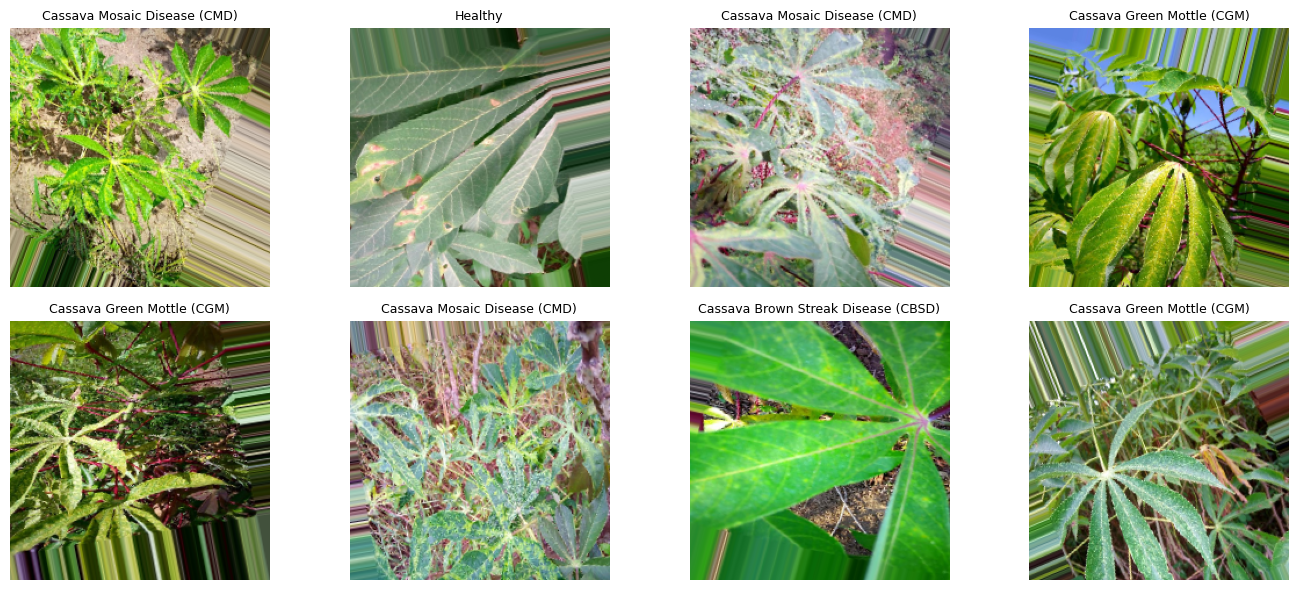

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    # de-normalize just for display purposes
    img = images[i] - images[i].min()
    img = img / (img.max() + 1e-8)
    ax.imshow(img)
    cls_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Feature interpretation #1 — Class distribution

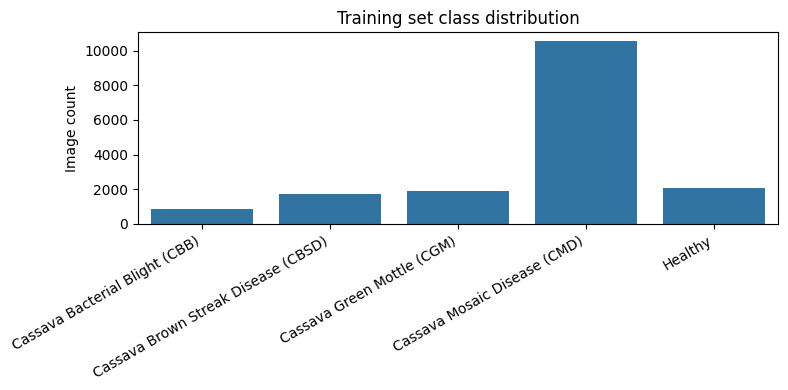

{'Cassava Bacterial Blight (CBB)': 870, 'Cassava Brown Streak Disease (CBSD)': 1752, 'Cassava Green Mottle (CGM)': 1909, 'Cassava Mosaic Disease (CMD)': 10527, 'Healthy': 2062}


In [11]:
from pathlib import Path
import seaborn as sns

counts = {cls: len(list(Path(f"../data/train/{cls}").glob("*.*"))) for cls in CLASS_NAMES}
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Image count")
plt.title("Training set class distribution")
plt.tight_layout()
plt.show()
print(counts)


**Interpretation:** Cassava Mosaic Disease (CMD) dominates the training set, reflecting its real-world prevalence as the most common cassava disease in East African fields. This imbalance is why the pipeline uses class-weighted loss (below) rather than relying on raw accuracy alone.

### Feature interpretation #2 — Average brightness per class

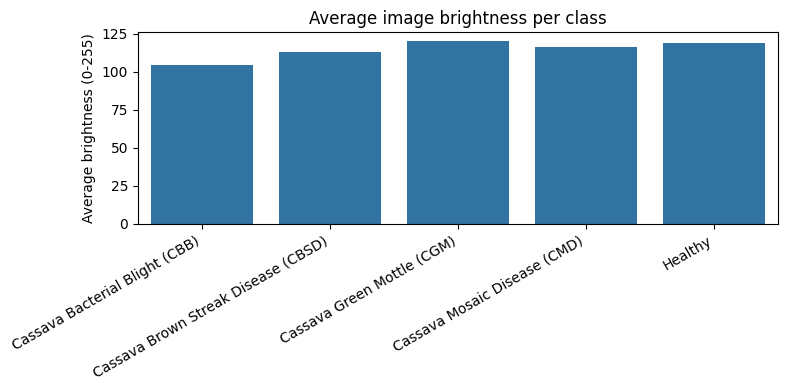

{'Cassava Bacterial Blight (CBB)': np.float64(104.79457713541667), 'Cassava Brown Streak Disease (CBSD)': np.float64(113.33061989583334), 'Cassava Green Mottle (CGM)': np.float64(120.07958734374999), 'Cassava Mosaic Disease (CMD)': np.float64(116.16971932291668), 'Healthy': np.float64(119.12904708333333)}


In [12]:
from PIL import Image

brightness = {}
for cls in CLASS_NAMES:
    files = list(Path(f"../data/train/{cls}").glob("*.*"))[:40]
    vals = [np.array(Image.open(f).convert("L")).mean() for f in files]
    if vals:
        brightness[cls] = np.mean(vals)

plt.figure(figsize=(8,4))
sns.barplot(x=list(brightness.keys()), y=list(brightness.values()))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average brightness (0-255)")
plt.title("Average image brightness per class")
plt.tight_layout()
plt.show()
print(brightness)


**Interpretation:** Diseases causing visible discoloration or necrosis (e.g. CBSD, CBB) shift average brightness relative to Healthy leaves, which tend to be more uniformly green. This gives the model a genuine low-level visual signal beyond texture alone.

### Feature interpretation #3 — Image resolution consistency

In [13]:
res = {}
for cls in CLASS_NAMES:
    files = list(Path(f"../data/train/{cls}").glob("*.*"))[:40]
    dims = [Image.open(f).size for f in files]
    if dims:
        res[cls] = (np.mean([d[0] for d in dims]), np.mean([d[1] for d in dims]))

for cls, (w, h) in res.items():
    print(f"{cls:40s} avg_width={w:.0f}  avg_height={h:.0f}")


Cassava Bacterial Blight (CBB)           avg_width=800  avg_height=600
Cassava Brown Streak Disease (CBSD)      avg_width=800  avg_height=600
Cassava Green Mottle (CGM)               avg_width=800  avg_height=600
Cassava Mosaic Disease (CMD)             avg_width=800  avg_height=600
Healthy                                  avg_width=800  avg_height=600


**Interpretation:** Consistent resolution across classes indicates images were captured under similar field-survey conditions, reducing the chance the model learns capture-device artifacts rather than genuine disease features.

## 3. Model Creation\n\nEfficientNetB0 pretrained on ImageNet, partially fine-tuned (layers 200+ trainable), with a dense head using L2 regularization, batch normalization, and dropout (0.4).

In [14]:
from src.model import build_model, train_model, evaluate_model, save_model_as_h5, MODEL_PATH

model = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,816 (16.71 MB)

 Trainable params: 2,380,437 (9.08 MB)

 Non-trainable params: 1,999,379 (7.63 MB)

### Class weights\n\nCompensates for the class imbalance shown above.

In [15]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(3.9335135135135135), 1: np.float64(1.9535570469798658), 2: np.float64(1.7934688847812692), 3: np.float64(0.32530174340634777), 4: np.float64(1.660467769537935)}


## 4. Model Training\n\nEarly stopping, LR scheduling on plateau, and checkpointing the best epoch.

In [16]:
import tensorflow as tf

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True),
    ],
)


Epoch 1/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.3318 - loss: 1.9703

455/455 ━━━━━━━━━━━━━━━━━━━━ 344s 664ms/step - accuracy: 0.3964 - loss: 1.7408 - val_accuracy: 0.5791 - val_loss: 1.1952 - learning_rate: 1.0000e-04
Epoch 2/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.5265 - loss: 1.3703

455/455 ━━━━━━━━━━━━━━━━━━━━ 253s 557ms/step - accuracy: 0.5431 - loss: 1.3324 - val_accuracy: 0.6115 - val_loss: 1.1496 - learning_rate: 1.0000e-04
Epoch 3/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.5794 - loss: 1.2037

455/455 ━━━━━━━━━━━━━━━━━━━━ 253s 556ms/step - accuracy: 0.5930 - loss: 1.1872 - val_accuracy: 0.6707 - val_loss: 1.0094 - learning_rate: 1.0000e-04
Epoch 4/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.6305 - loss: 1.0666

455/455 ━━━━━━━━━━━━━━━━━━━━ 256s 563ms/step - accuracy: 0.6383 - loss: 1.0742 - val_accuracy: 0.6933 - val_loss: 0.9256 - learning_rate: 1.0000e-04
Epoch 5/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 258s 567ms/step - accuracy: 0.6587 - loss: 1.0172 - val_accuracy: 0.6867 - val_loss: 0.9389 - learning_rate: 1.0000e-04
Epoch 6/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6818 - loss: 0.9299

...

455/455 ━━━━━━━━━━━━━━━━━━━━ 252s 555ms/step - accuracy: 0.7213 - loss: 0.8455 - val_accuracy: 0.7299 - val_loss: 0.8235 - learning_rate: 1.0000e-04
Epoch 9/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7376 - loss: 0.7953

455/455 ━━━━━━━━━━━━━━━━━━━━ 253s 555ms/step - accuracy: 0.7309 - loss: 0.8033 - val_accuracy: 0.7385 - val_loss: 0.8126 - learning_rate: 1.0000e-04
Epoch 10/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.7340 - loss: 0.8037

455/455 ━━━━━━━━━━━━━━━━━━━━ 255s 561ms/step - accuracy: 0.7389 - loss: 0.7800 - val_accuracy: 0.7463 - val_loss: 0.8073 - learning_rate: 1.0000e-04
Epoch 11/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7535 - loss: 0.7143

455/455 ━━━━━━━━━━━━━━━━━━━━ 253s 557ms/step - accuracy: 0.7503 - loss: 0.7305 - val_accuracy: 0.7225 - val_loss: 0.8058 - learning_rate: 1.0000e-04
Epoch 12/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 251s 551ms/step - accuracy: 0.7622 - loss: 0.7136 - val_accuracy: 0.7377 - val_loss: 0.8271 - learning_rate: 1.0000e-04
Epoch 13/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.7649 - loss: 0.6810

455/455 ━━━━━━━━━━━━━━━━━━━━ 254s 558ms/step - accuracy: 0.7667 - loss: 0.6818 - val_accuracy: 0.7459 - val_loss: 0.7868 - learning_rate: 1.0000e-04
Epoch 14/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 255s 561ms/step - accuracy: 0.7774 - loss: 0.6578 - val_accuracy: 0.7440 - val_loss: 0.8220 - learning_rate: 1.0000e-04
Epoch 15/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 251s 552ms/step - accuracy: 0.7897 - loss: 0.6094 - val_accuracy: 0.7471 - val_loss: 0.7879 - learning_rate: 1.0000e-04


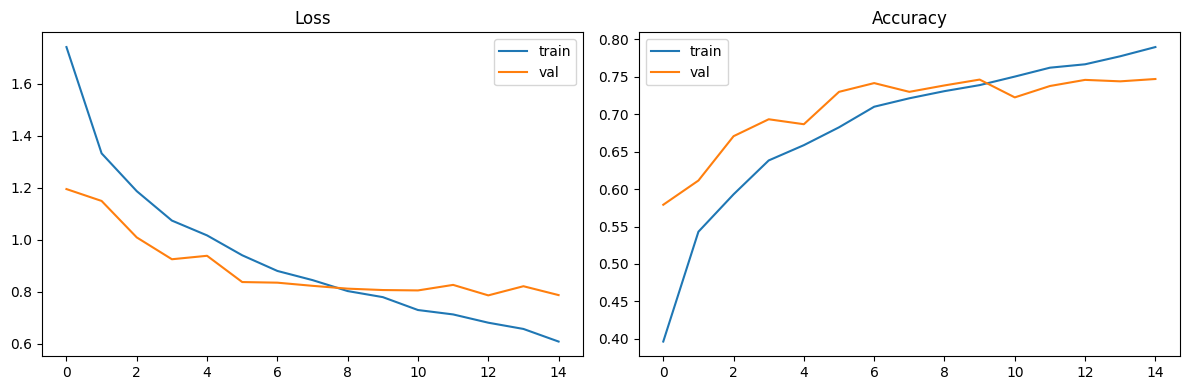

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Model Testing / Evaluation\n\nFour+ metrics: **accuracy, precision (macro), recall (macro), F1 (macro)**, plus loss, confusion matrix, and full classification report — evaluated on the held-out test set **that the model never saw during training**.

In [18]:
save_model_as_h5(model)
print(f"Model saved to: {MODEL_PATH}")

metrics = evaluate_model(model, test_gen)
print(f"Loss:      {metrics['loss']:.4f}")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision_macro']:.4f}")
print(f"Recall:    {metrics['recall_macro']:.4f}")
print(f"F1 score:  {metrics['f1_macro']:.4f}")


Model saved to: models/cassava_efficientnet.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 40s 240ms/step
Loss:      0.9133
Accuracy:  0.7157
Precision: 0.6071
Recall:    0.6515
F1 score:  0.6046


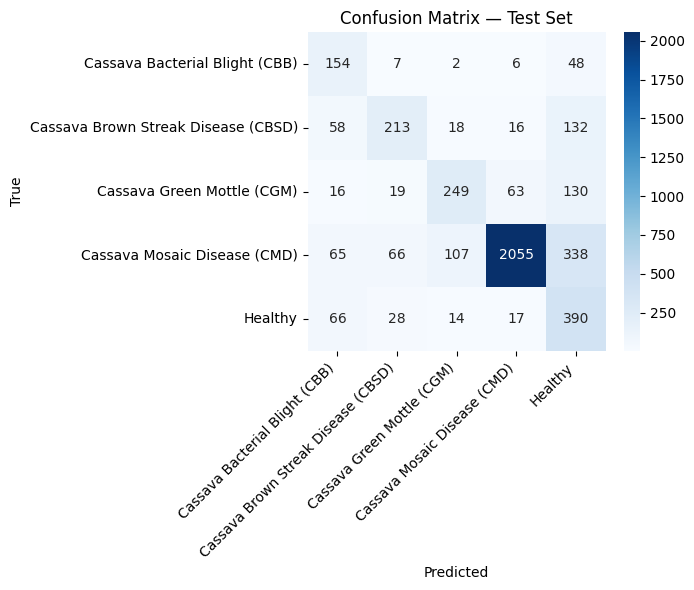

In [19]:
cm = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


In [20]:
import json
print(json.dumps(metrics["classification_report"], indent=2))


{
  "Cassava Bacterial Blight (CBB)": {
    "precision": 0.42896935933147634,
    "recall": 0.7096774193548387,
    "f1-score": 0.5347222222222222,
    "support": 217.0
  },
  "Cassava Brown Streak Disease (CBSD)": {
    "precision": 0.6396396396396397,
    "recall": 0.4874141876430206,
    "f1-score": 0.5532467532467532,
    "support": 437.0
  },
  "Cassava Green Mottle (CGM)": {
    "precision": 0.6384615384615384,
    "recall": 0.5220125786163522,
    "f1-score": 0.5743944636678201,
    "support": 477.0
  },
  "Cassava Mosaic Disease (CMD)": {
    "precision": 0.952712100139082,
    "recall": 0.7810718358038768,
    "f1-score": 0.8583959899749374,
    "support": 2631.0
  },
  "Healthy": {
    "precision": 0.37572254335260113,
    "recall": 0.7572815533980582,
    "f1-score": 0.5022537025112686,
    "support": 515.0
  },
  "accuracy": 0.7156885667523966,
  "macro avg": {
    "precision": 0.6071010361848675,
    "recall": 0.6514915149632293,
    "f1-score": 0.6046026263246003,
    "su

## 6. Single-Image Prediction Demo\n\nMirrors what the `/predict` API endpoint does.

True folder label: Healthy
Prediction: Healthy (63.4% confidence)


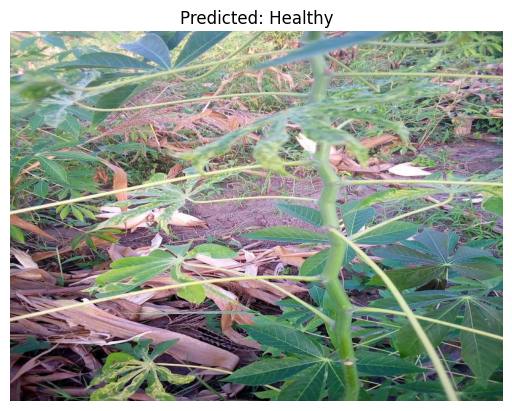

In [21]:
from src.prediction import predict_image

sample_file = next(Path("../data/test").rglob("*.jpg"), None)
if sample_file:
    result = predict_image(str(sample_file))
    print("True folder label:", sample_file.parent.name)
    print("Prediction:", result["predicted_class"], f"({result['confidence']*100:.1f}% confidence)")
    plt.imshow(plt.imread(sample_file))
    plt.title(f"Predicted: {result['predicted_class']}")
    plt.axis("off")
    plt.show()


## 7. Retraining Demonstration

Simulates the pipeline's retraining trigger: new bulk-uploaded images are ingested into
`data/train/<class>/`, and the model is fine-tuned further from its existing saved weights
(not from scratch), then re-evaluated. This mirrors exactly what `POST /retrain` on the
FastAPI backend does (`src/model.py::retrain()`).


In [26]:
import os
os.chdir("..")

from src.model import retrain
new_metrics = retrain(epochs=3)
print(f"Retrained accuracy: {new_metrics['accuracy']:.4f}")
print(f"Retrained F1:       {new_metrics['f1_macro']:.4f}")

os.chdir("notebook")

Found 14554 images belonging to 5 classes.
Found 2566 images belonging to 5 classes.
Found 4277 images belonging to 5 classes.


Epoch 1/3
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.4286 - loss: 1.6466

455/455 ━━━━━━━━━━━━━━━━━━━━ 313s 627ms/step - accuracy: 0.5251 - loss: 1.4228 - val_accuracy: 0.7069 - val_loss: 0.8949 - learning_rate: 1.0000e-04
Epoch 2/3
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6563 - loss: 1.0986

455/455 ━━━━━━━━━━━━━━━━━━━━ 257s 566ms/step - accuracy: 0.6670 - loss: 1.0565 - val_accuracy: 0.7428 - val_loss: 0.8029 - learning_rate: 1.0000e-04
Epoch 3/3
455/455 ━━━━━━━━━━━━━━━━━━━━ 258s 567ms/step - accuracy: 0.6969 - loss: 0.9593 - val_accuracy: 0.7303 - val_loss: 0.8164 - learning_rate: 1.0000e-04


134/134 ━━━━━━━━━━━━━━━━━━━━ 34s 198ms/step
Retrained accuracy: 0.7169
Retrained F1:       0.5080


In [30]:
from google.colab import files
files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>